# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Kadek Nathania Gavrila Astika | 5054251050 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

RANDOM_STATE = 42

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv("bankruptcy.csv")

# Nama kolom asli punya spasi di depan, dirapikan
df.columns = df.columns.str.strip()

# Jumlah baris dan kolom
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

# Tipe data (sekaligus jumlah non-null per kolom)
df.info()

# Jumlah missing value
print("\nTotal missing value:", df.isnull().sum().sum())

# Statistik deskriptif
df.describe().T

Jumlah baris: 6819
Jumlah kolom: 96
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   Pre-tax net Interest Rate                                6819 non-null   float

,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
...,...,...,...,...,...,...,...,...
Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0
Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0


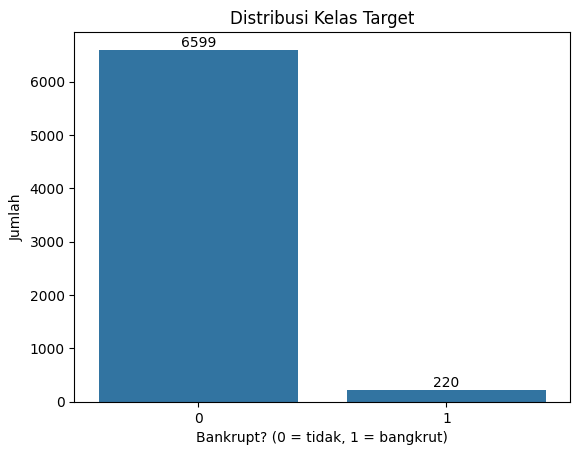

Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64


In [3]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
ax = sns.countplot(data=df, x='Bankrupt?')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribusi Kelas Target')
plt.xlabel('Bankrupt? (0 = tidak, 1 = bangkrut)')
plt.ylabel('Jumlah')
plt.show()

print(df['Bankrupt?'].value_counts(normalize=True).round(4) * 100)

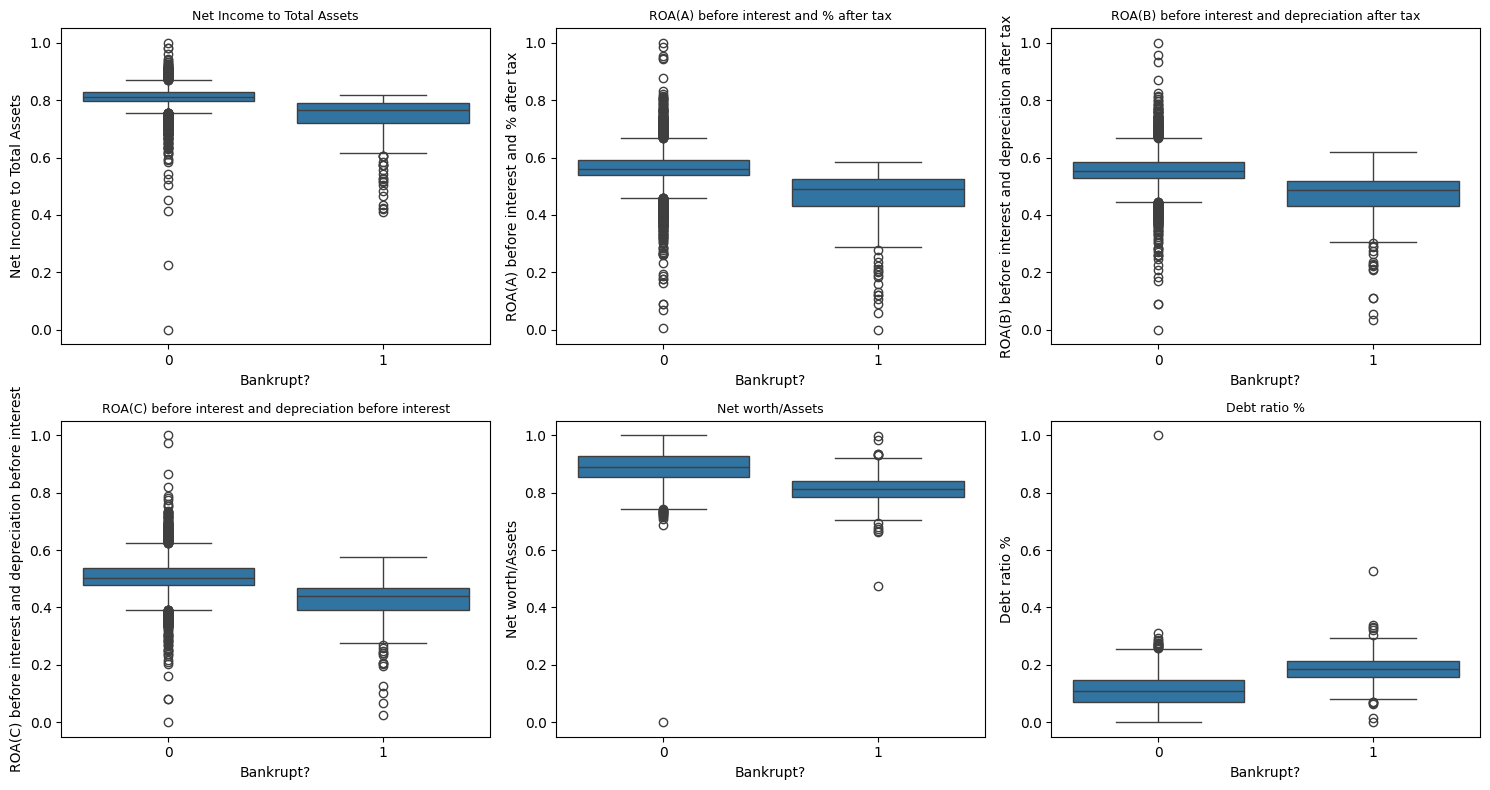

In [4]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.
top_feats = df.corr()['Bankrupt?'].drop('Bankrupt?').abs().sort_values(ascending=False).head(6).index

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.ravel(), top_feats):
    sns.boxplot(data=df, x='Bankrupt?', y=feat, ax=ax)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('Bankrupt?')
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

In [5]:
# 1. Duplikat
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


In [6]:
# 2. Kolom konstan
const_cols = [col for col in df.columns if df[col].nunique() == 1]
print("Kolom konstan:", const_cols)

Kolom konstan: ['Net Income Flag']


In [7]:
# 3. Skala nilai: fitur dengan nilai maksimum > 1 (mayoritas fitur lain di rentang 0-1)
big = df.max().drop("Bankrupt?")
big = big[big > 1].sort_values(ascending=False)
print(f"\nJumlah fitur dengan nilai maks > 1: {len(big)}")
print(big.head(10))


Jumlah fitur dengan nilai maks > 1: 24
Cash Turnover Rate                       1.000000e+10
Current Asset Turnover Rate              1.000000e+10
Quick Asset Turnover Rate                1.000000e+10
Operating Expense Rate                   9.990000e+09
Inventory Turnover Rate (times)          9.990000e+09
Total Asset Growth Rate                  9.990000e+09
Fixed Assets Turnover Frequency          9.990000e+09
Research and development expense rate    9.980000e+09
Total debt/Total net worth               9.940000e+09
Inventory/Current Liability              9.910000e+09
dtype: float64


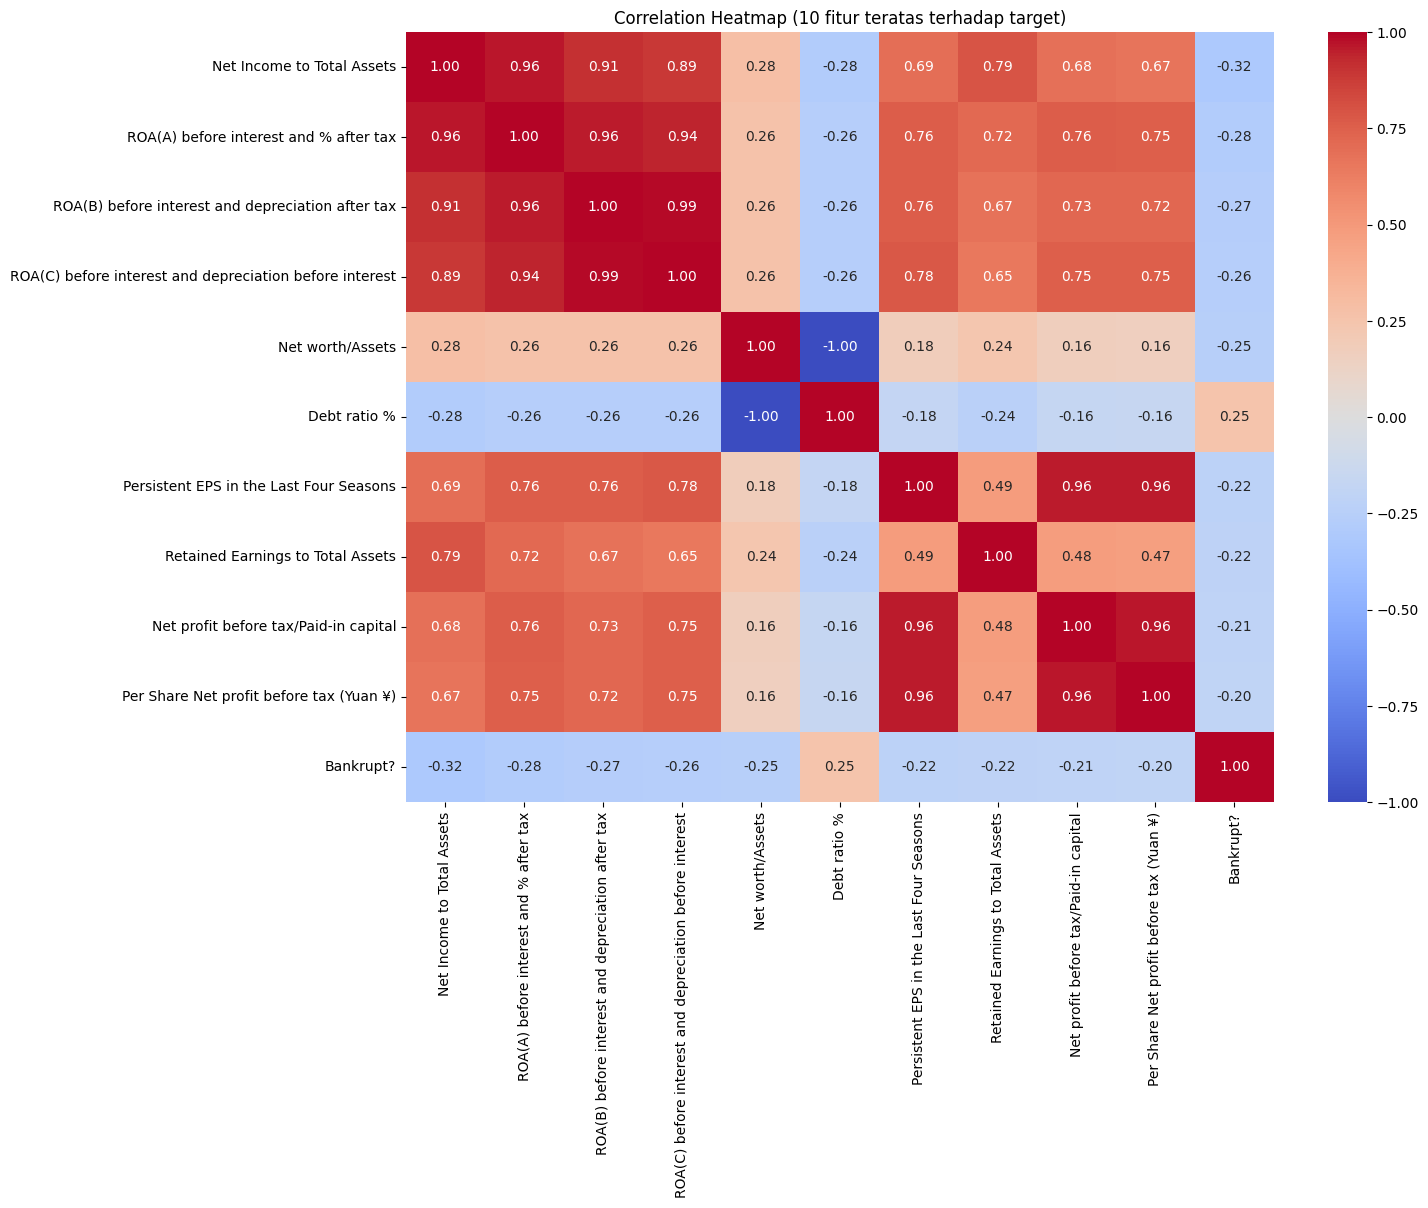

In [8]:
# 4. Korelasi: 10 fitur dengan korelasi (absolut) tertinggi terhadap target
top_feats = (
    df.corr()["Bankrupt?"]
    .drop("Bankrupt?")
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    df[list(top_feats) + ["Bankrupt?"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap (10 fitur teratas terhadap target)")
plt.show()

# 2. Preprocessing

In [9]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
print("Missing value per kolom (yang > 0):")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("Total:", df.isnull().sum().sum())

Missing value per kolom (yang > 0):
Series([], dtype: int64)
Total: 0


In [10]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.
categorical_cols = df.select_dtypes(
    include=["object", "bool"]
).columns

print("Fitur kategorikal:", categorical_cols.tolist())

Fitur kategorikal: []


In [11]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns='Bankrupt?')
y = df['Bankrupt?']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Proporsi kelas 1 (bangkrut) -> train: {:.2%}, test: {:.2%}".format(y_train.mean(), y_test.mean()))

Train: (5455, 95) | Test: (1364, 95)
Proporsi kelas 1 (bangkrut) -> train: 3.23%, test: 3.23%


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [12]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=RANDOM_STATE)
dt_gini.fit(X_train, y_train)

print("Kedalaman pohon:", dt_gini.get_depth(), "| Jumlah daun:", dt_gini.get_n_leaves())

Kedalaman pohon: 20 | Jumlah daun: 124


In [13]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_gini = dt_gini.predict(X_test)
print("Akurasi test (Gini):", round(accuracy_score(y_test, y_pred_gini), 4))

Akurasi test (Gini): 0.9611


## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [14]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_STATE)
dt_entropy.fit(X_train, y_train)

print("Kedalaman pohon:", dt_entropy.get_depth(), "| Jumlah daun:", dt_entropy.get_n_leaves())

Kedalaman pohon: 17 | Jumlah daun: 99


In [15]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_entropy = dt_entropy.predict(X_test)
print("Akurasi test (Entropy):", round(accuracy_score(y_test, y_pred_entropy), 4))

Akurasi test (Entropy): 0.9641


## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [16]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).
# Karena data sangat imbalanced, "terbaik" ditentukan dari F1-score kelas bangkrut, bukan akurasi
f1_gini = f1_score(y_test, y_pred_gini)
f1_entropy = f1_score(y_test, y_pred_entropy)
best_criterion = 'gini' if f1_gini >= f1_entropy else 'entropy'
print(f"F1 Gini = {f1_gini:.4f} | F1 Entropy = {f1_entropy:.4f} -> kriteria dipakai: {best_criterion}")

depth_values = [1, 2, 3, 5, 10, None]
depth_models = {}
for d in depth_values:
    depth_models[d] = DecisionTreeClassifier(
        criterion=best_criterion, max_depth=d, random_state=RANDOM_STATE
    ).fit(X_train, y_train)

F1 Gini = 0.4045 | F1 Entropy = 0.4096 -> kriteria dipakai: entropy


In [17]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
rows = []
for d, m in depth_models.items():
    rows.append({
        'max_depth': str(d),
        'train_acc': accuracy_score(y_train, m.predict(X_train)),
        'test_acc': accuracy_score(y_test, m.predict(X_test)),
        'test_f1': f1_score(y_test, m.predict(X_test)),   # tambahan: akurasi saja menyesatkan pada data imbalanced
    })
depth_df = pd.DataFrame(rows)
print("Akurasi baseline (selalu tebak 'tidak bangkrut'): {:.4f}".format(1 - y_test.mean()))
depth_df.round(4)

Akurasi baseline (selalu tebak 'tidak bangkrut'): 0.9677


,max_depth,train_acc,test_acc,test_f1
0,1,0.9677,0.9677,0.0000
1,2,0.9677,0.9677,0.0000
2,3,0.9683,0.9699,0.2264
3,5,0.9743,0.9663,0.4390
4,10,0.9930,0.9633,0.3902
5,None,1.0000,0.9641,0.4096


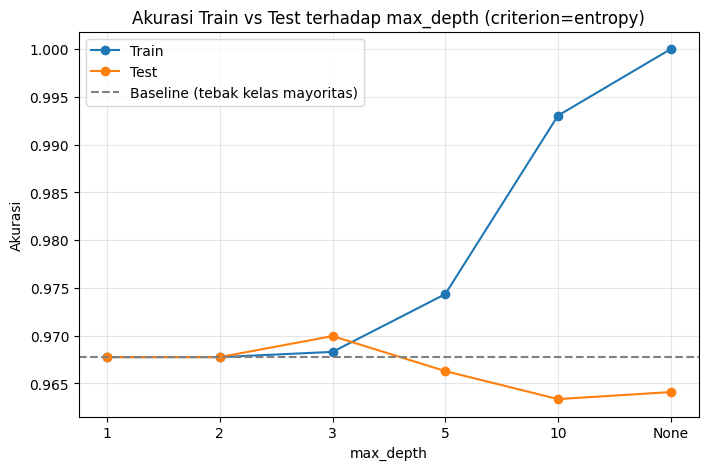

In [18]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
plt.figure(figsize=(8, 5))
plt.plot(depth_df['max_depth'], depth_df['train_acc'], marker='o', label='Train')
plt.plot(depth_df['max_depth'], depth_df['test_acc'], marker='o', label='Test')
plt.axhline(1 - y_test.mean(), color='gray', linestyle='--', label='Baseline (tebak kelas mayoritas)')
plt.title(f'Akurasi Train vs Test terhadap max_depth (criterion={best_criterion})')
plt.xlabel('max_depth')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 4. Evaluasi Model

In [19]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
def evaluate(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
    }

metrics_df = pd.DataFrame({
    'Gini': evaluate(y_test, y_pred_gini),
    'Entropy': evaluate(y_test, y_pred_entropy),
}).T
metrics_df.round(4)

,Accuracy,Precision,Recall,F1-Score
Gini,0.9611,0.4000,0.4091,0.4045
Entropy,0.9641,0.4359,0.3864,0.4096


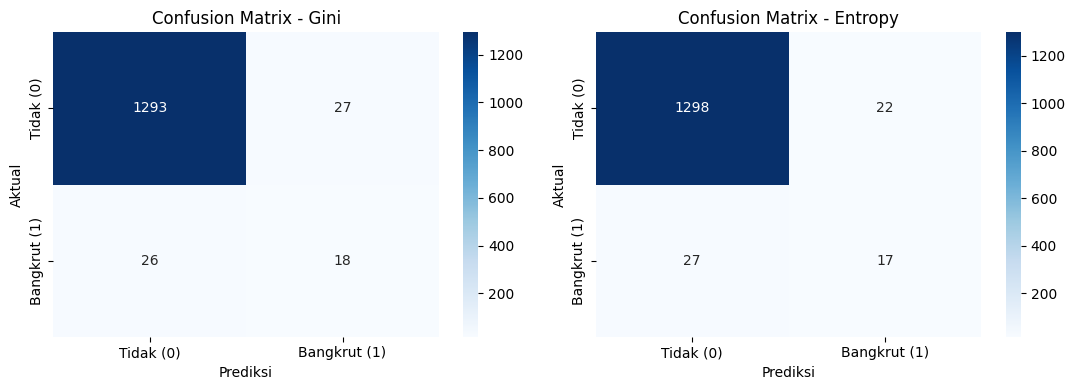

In [20]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, pred) in zip(axes, [('Gini', y_pred_gini), ('Entropy', y_pred_entropy)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Tidak (0)', 'Bangkrut (1)'], yticklabels=['Tidak (0)', 'Bangkrut (1)'])
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
plt.tight_layout()
plt.show()

Model terbaik: Entropy


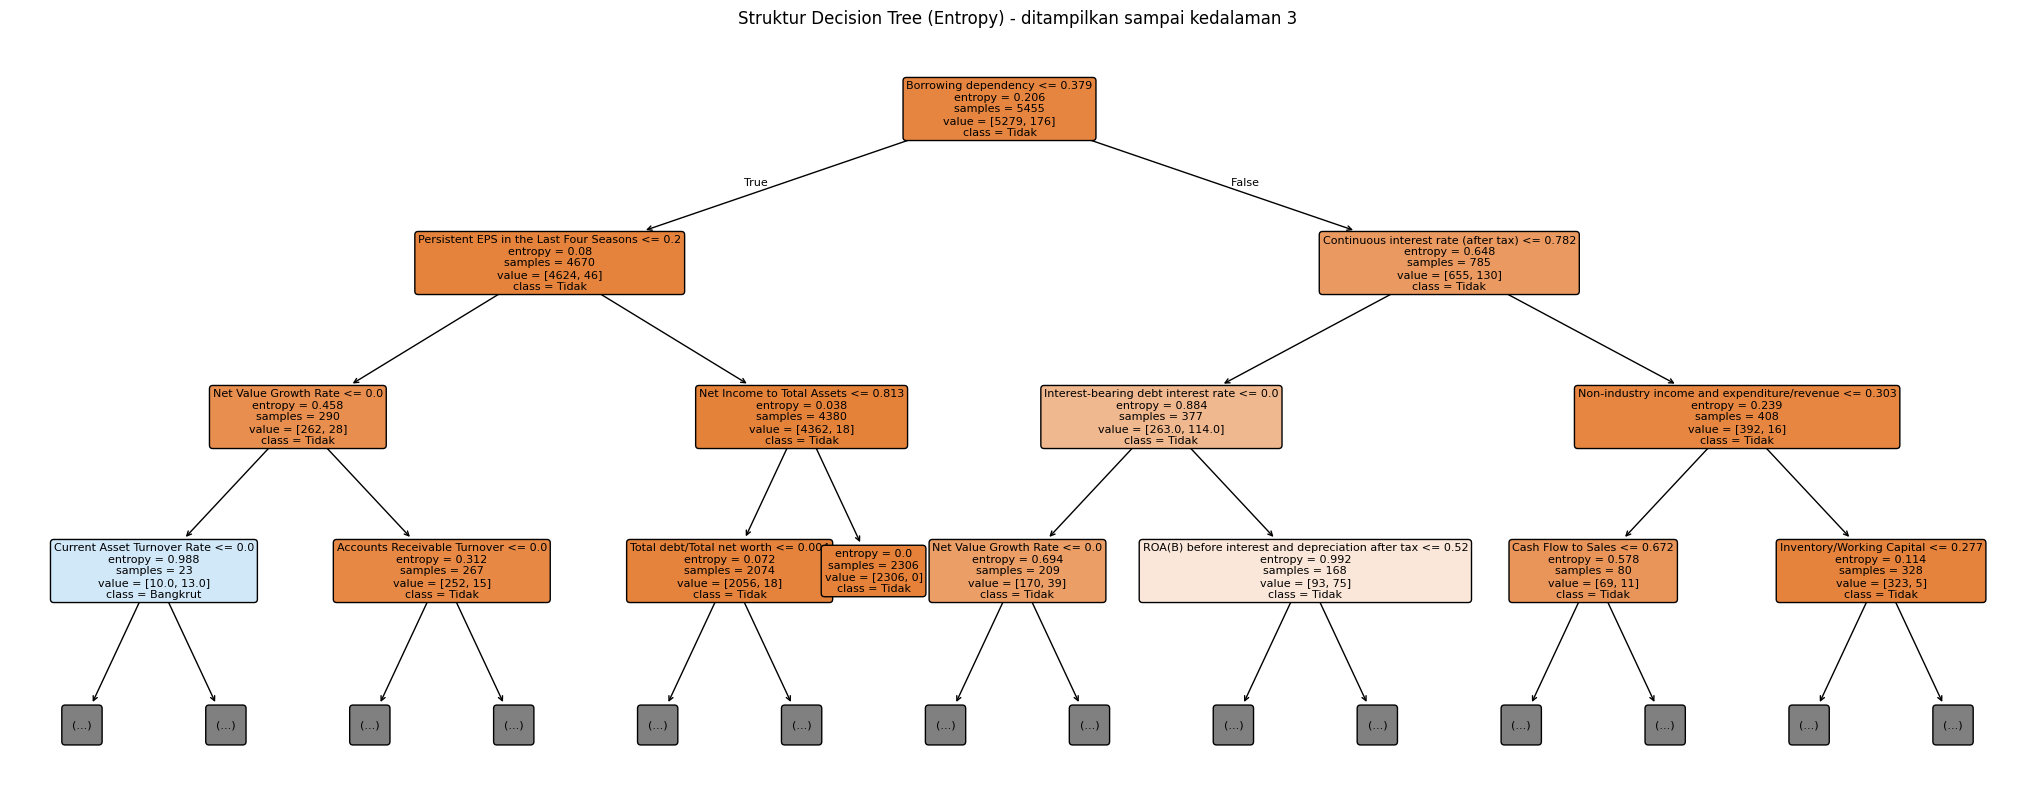

In [21]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.
# Model terbaik = model dengan F1 test tertinggi di antara Gini dan Entropy
best_name = 'Gini' if f1_gini >= f1_entropy else 'Entropy'
best_model = dt_gini if best_name == 'Gini' else dt_entropy
print("Model terbaik:", best_name)

plt.figure(figsize=(26, 10))
plot_tree(best_model, max_depth=3, feature_names=X.columns, class_names=['Tidak', 'Bangkrut'],
          filled=True, rounded=True, fontsize=8)
plt.title(f'Struktur Decision Tree ({best_name}) - ditampilkan sampai kedalaman 3')
plt.show()

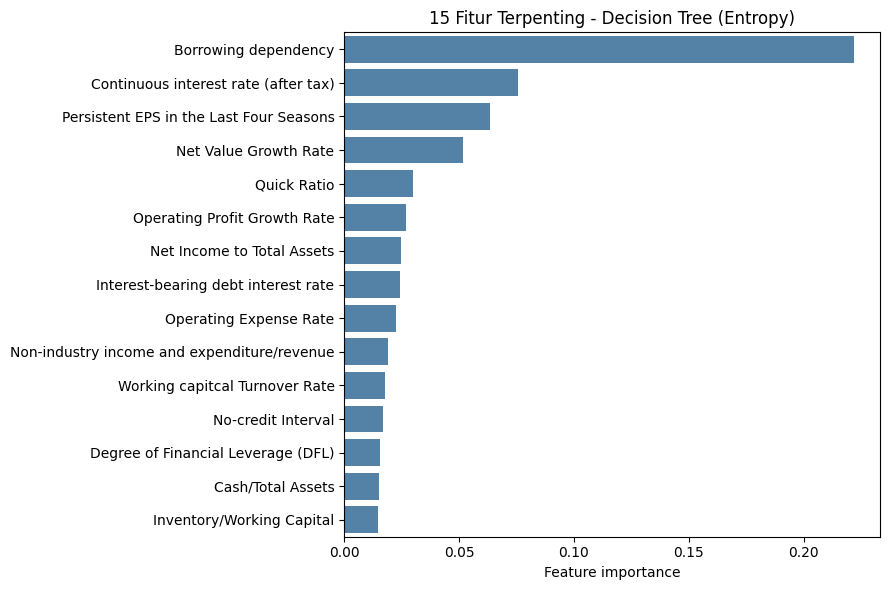

Borrowing dependency                           0.2221
Continuous interest rate (after tax)           0.0758
Persistent EPS in the Last Four Seasons        0.0635
Net Value Growth Rate                          0.0517
Quick Ratio                                    0.0298
Operating Profit Growth Rate                   0.0270
Net Income to Total Assets                     0.0247
Interest-bearing debt interest rate            0.0242
Operating Expense Rate                         0.0225
Non-industry income and expenditure/revenue    0.0189
Working capitcal Turnover Rate                 0.0177
No-credit Interval                             0.0170
Degree of Financial Leverage (DFL)             0.0158
Cash/Total Assets                              0.0151
Inventory/Working Capital                      0.0145
dtype: float64


In [22]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
top15 = importances.head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=top15.values, y=top15.index, color='steelblue')
plt.title(f'15 Fitur Terpenting - Decision Tree ({best_name})')
plt.xlabel('Feature importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

print(top15.round(4))

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa Decision Tree dengan kriteria Gini vs Entropy. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (max_depth). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Fitur apa yang paling berpengaruh terhadap prediksi model, berdasarkan feature importance?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

**Jawab:**

**Gambaran umum.** Data tidak seimbang (3,23% bangkrut), sehingga model yang selalu menebak "tidak bangkrut" sudah mendapat akurasi 96,77% di test set. Karena itu akurasi tidak bisa dipakai sendirian; perbandingan model lebih tepat dilihat dari Precision, Recall, dan F1 untuk kelas bangkrut.

**1. Gini vs Entropy**

| Model | Accuracy | Precision | Recall | F1 | TP | FP | FN |
|---|---|---|---|---|---|---|---|
| Gini | 0,9611 | 0,4000 | 0,4091 | 0,4045 | 18 | 27 | 26 |
| Entropy | 0,9641 | 0,4359 | 0,3864 | 0,4096 | 17 | 22 | 27 |

Hasilnya hampir sama. Entropy unggul tipis pada akurasi (+0,3 poin), precision, dan F1 (+0,5 poin), sedangkan Gini sedikit lebih tinggi pada recall. Selisihnya hanya satu perusahaan bangkrut yang terdeteksi (18 vs 17) dan lima false positive; dengan hanya 44 perusahaan bangkrut di test set, perbedaan sekecil ini tidak bisa dianggap signifikan. Hal ini masuk akal karena Gini dan Entropy sama-sama mengukur ketidakmurnian node dengan bentuk kurva yang mirip (nol saat node murni, maksimum saat kelas 50:50), sehingga split terbaik yang dipilih sering kali sama atau hampir sama. Pohon Entropy sedikit lebih ringkas (kedalaman 17 dengan 99 daun, dibanding 20 dengan 124 daun pada Gini). Perlu dicatat, kedua model punya akurasi (96,11% dan 96,41%) yang justru sedikit di bawah baseline 96,77%, dan recall-nya hanya sekitar 39-41%: lebih dari separuh perusahaan yang benar-benar bangkrut tidak terdeteksi.

**2. Pengaruh max_depth (criterion = entropy)**

| max_depth | Train acc | Test acc | Test F1 |
|---|---|---|---|
| 1 | 0,9677 | 0,9677 | 0,0000 |
| 2 | 0,9677 | 0,9677 | 0,0000 |
| 3 | 0,9683 | 0,9699 | 0,2264 |
| 5 | 0,9743 | 0,9663 | 0,4390 |
| 10 | 0,9930 | 0,9633 | 0,3902 |
| None | 1,0000 | 0,9641 | 0,4096 |

- **Underfitting (max_depth 1-2):** akurasi train = test = baseline dan F1 = 0, artinya pohon terlalu dangkal dan hanya memprediksi kelas mayoritas.
- **Titik terbaik (max_depth 3-5):** akurasi test tertinggi ada di max_depth 3 (0,9699), sedangkan F1 tertinggi ada di max_depth 5 (0,4390). Pada kedalaman ini selisih train-test masih kecil (sekitar -0,2 poin pada depth 3 dan 0,8 poin pada depth 5).
- **Overfitting (mulai setelah max_depth 3-5, jelas di 10 ke atas):** akurasi train terus naik sampai 100% pada pohon tanpa batas, sedangkan akurasi test berhenti naik setelah depth 3 lalu turun dan bertahan di sekitar 0,963-0,966. Pada grafik, kedua garis yang awalnya berimpit melebar menjadi celah 3,0 poin (depth 10) dan 3,6 poin (None). Pohon tanpa batas menghafal data train, tetapi tidak lebih baik pada data baru.
- Selisih akurasi test antar depth kecil (misalnya 0,9699 vs 0,9633 hanya sekitar 9 sampel dari 1.364), jadi hasil ini lebih tepat dibaca sebagai tren daripada angka pasti.

**3. Feature importance (model Entropy)**

Fitur paling berpengaruh adalah **Borrowing dependency** (0,2221), hampir tiga kali fitur kedua. Disusul Continuous interest rate (after tax) (0,0758), Persistent EPS in the Last Four Seasons (0,0635), Net Value Growth Rate (0,0517), dan Quick Ratio (0,0298). Borrowing dependency juga menjadi split di root node pohon. Fitur-fitur teratas ini terkait ketergantungan pada utang dan beban bunga (tekanan keuangan) serta profitabilitas dan pertumbuhan, yang secara logika berhubungan dengan risiko bangkrut. Namun importance ini berasal dari pohon yang dalam dan overfit, sehingga bisa berubah jika data di-split ulang. Fitur ROA yang berkorelasi tinggi dengan target pada EDA juga tidak masuk 15 besar; kemungkinan karena banyak fitur yang saling berkorelasi sehingga pohon cukup memilih salah satu saja.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba pruning dengan ccp_alpha, membandingkan dengan model lain, atau mencoba variasi hyperparameter lain seperti min_samples_leaf), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

**Jawab:**

**Kesimpulan**
1. Dataset sangat imbalanced (3,23% bangkrut), sehingga akurasi ~96% menyesatkan karena baseline yang selalu menebak kelas mayoritas sudah 96,77%. Model terbaik yang diperoleh baru mencapai F1 sekitar 0,41 (recall sekitar 39-41%) pada kelas bangkrut.
2. Gini dan Entropy menghasilkan performa yang hampir sama (F1 0,4045 vs 0,4096). Entropy dipilih sebagai model terbaik karena sedikit lebih baik dan pohonnya lebih kecil, tetapi selisihnya tidak signifikan.
3. Pohon tanpa batas kedalaman overfitting (train 100%, test 96,41%). max_depth sekitar 3-5 adalah kompromi terbaik; max_depth 5 memberi F1 test tertinggi (0,4390), sedangkan max_depth 1-2 underfitting.
4. Fitur paling berpengaruh adalah Borrowing dependency, diikuti Continuous interest rate (after tax) dan Persistent EPS in the Last Four Seasons.

**Saran**
- Terapkan pruning dengan `ccp_alpha` dan atur `min_samples_leaf` untuk mengendalikan overfitting secara lebih halus daripada hanya `max_depth`.
- Tangani imbalance dengan `class_weight='balanced'` (atau resampling seperti SMOTE hanya pada train set), lalu evaluasi dengan recall, F1, atau PR-AUC. Threshold prediksi juga bisa disesuaikan.
- Gunakan Stratified K-Fold Cross Validation dan GridSearchCV; hasil pada satu kali split dengan hanya 44 sampel bangkrut di test set sangat sensitif terhadap variasi data.
- Bandingkan dengan model ensemble seperti Random Forest atau Gradient Boosting, yang umumnya lebih stabil daripada satu pohon tunggal.